In [40]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_hist_data(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    data = np.load(path, allow_pickle=True)
    keys = list(data.keys())
    if 'values' in data:
        return {'type':'values', 'values': np.asarray(data['values'])}
    if 'counts' in data and 'edges' in data:
        return {'type':'hist', 'counts': np.asarray(data['counts']), 'edges': np.asarray(data['edges'])}
    # Fallbacks: single array saved without a name or first array
    if len(keys) == 1:
        arr = np.asarray(data[keys[0]])
        return {'type':'values', 'values': arr}
    raise ValueError('Unknown NPZ contents: ' + ','.join(keys))

a = load_hist_data('theta_error_histogram_data.npz')
b = load_hist_data('theta_error_histogram_upside.npz')

a['edges'].__len__(), a['counts'].__len__()

(101, 100)

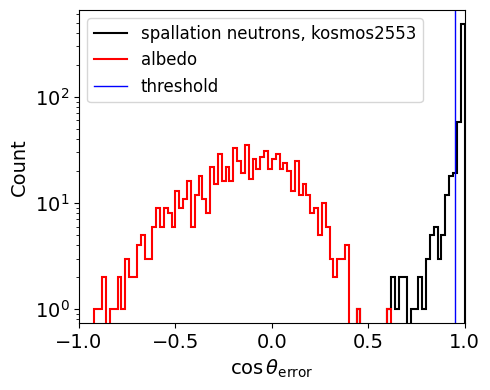

In [48]:
# Plot overlay with sensible defaults and matching bins when possible
plt.figure(figsize=(5,4))

# helper to plot when we have counts+edges
def plot_hist_from_hist(counts, edges, label, color, alpha=0.5):
    centers = 0.5 * (edges[:-1] + edges[1:])
    widths = np.diff(edges)
    plt.bar(centers, counts, width=widths, align='center', alpha=alpha, label=label, color=color, edgecolor='none')

# Decide common binning / plotting strategy
if a['type'] == 'hist' and b['type'] == 'hist':
    # If both pre-binned, plot both as stepped outlines so different bins remain visible
    edges_a = a['edges']
    edges_b = b['edges']
    plt.stairs(a['counts'], a['edges'], color='black', linewidth=1.5, label='spallation neutrons, kosmos2553')
    plt.stairs(b['counts'], b['edges'], color='red', linewidth=1.5, label='albedo')

#    plt.step(edges_b[:-1], b['counts'], where='post', color='red', linewidth=1.5, label='albedo')
    plt.axvline(x=0.95, color='blue', linestyle='-', linewidth=1,label='threshold')
    plt.xlim(-1,1)
elif a['type'] == 'hist' and b['type'] == 'values':
    # reuse edges from a for b so bins align
    plot_hist_from_hist(a['counts'], a['edges'], 'data (prebinned)', 'C0', alpha=0.6)
    plt.hist(b['values'], bins=a['edges'], alpha=0.4, color='C1', label='upside (values)')
elif a['type'] == 'values' and b['type'] == 'hist':
    plot_hist_from_hist(b['counts'], b['edges'], 'upside (prebinned)', 'C1', alpha=0.6)
    plt.hist(a['values'], bins=b['edges'], alpha=0.4, color='C0', label='data (values)')
else:
    # both are raw values — use a common binning (200 bins by default)
    bins = 200
    plt.hist(a['values'], bins=bins, alpha=0.5, color='C0', label='data (values)')
    plt.hist(b['values'], bins=bins, alpha=0.5, color='C1', label='upside (values)')

plt.xlabel(r'$\cos\theta_{\mathrm{error}}$', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.yscale('log')
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.savefig('theta_signal_albedo.pdf')
plt.show()
